# A proxy metric is a bet that a correlation survives being optimised

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/goodhart-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/goodhart-detector/demo.ipynb)

**Day 162 - `goodhart-detector`**

A team picks a proxy because it correlates with the outcome they care about. They
put a target on it. It goes up. Nobody can say whether the outcome followed.

The trouble with studying this on real data is that nobody knows the answer. So
this notebook writes the answer down first: a world with one latent quality
driver, one outcome, one proxy, and one exploit that moves the proxy without
moving the driver. Then it points seven detectors at it and measures which ones
notice, how late, and how often they cry wolf.

**What the notebook shows**

1. A world where the exploit is cheaper than the work
2. The KPI improves; the outcome falls; the exchange rate
3. The correlation barely moves while half the outcome disappears
4. **The correlation falls without anyone gaming** - the winner's curse
5. Seven detectors, ranked, and the one that needs no outcome
6. Why the outcome arrives too late to help
7. Try your own

## 1. A world where the answer is known

Each agent splits its effort between doing the work and moving the number.

```
latent quality   L = skill + kappa*(1 - u)
outcome          y = a_y*L + noise
proxy            p = beta*L + gamma*u + noise
```

`u` is the share of effort diverted to the exploit. Diverting one unit buys
`gamma - beta*kappa` proxy points and destroys `a_y*kappa` outcome points. When
that first quantity is positive, the exploit is the *cheaper way to move the
number*, and that inequality is the whole of Goodhart's law here.

Nothing downstream is allowed to look at `u` or at `skill`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})
INK, RED, BLUE, GREEN, MUTED, PURPLE = "#141414", "#c0392b", "#4a7c8c", "#4b7f52", "#8a8a8a", "#7a5a8c"


@dataclass(frozen=True)
class World:
    n_agents: int = 600
    kappa: float = 0.60      # quality bought by honest effort
    a_y: float = 1.00        # outcome loading on quality
    sigma_y: float = 0.50
    beta: float = 1.00       # proxy loading on quality
    gamma: float = 1.10      # proxy loading on the exploit
    sigma_p: float = 0.50
    scruple_median: float = 1.80
    scruple_sigma: float = 0.50
    hazard: float = 0.35
    seed: int = 20260831

    @property
    def exploit_edge(self) -> float:
        return self.gamma - self.beta * self.kappa

    @property
    def outcome_cost(self) -> float:
        return self.a_y * self.kappa

    @property
    def payoff_ratio(self) -> float:
        return self.gamma / (self.beta * self.kappa)

    @property
    def rho_clean(self) -> float:
        return float(self.beta * self.a_y
                     / (np.hypot(self.beta, self.sigma_p) * np.hypot(self.a_y, self.sigma_y)))


W = World()
print(f"exploit buys  {W.exploit_edge:+.2f} proxy points per unit of diverted effort")
print(f"and costs     {W.outcome_cost:+.2f} outcome points")
print(f"the exploit pays {W.payoff_ratio:.2f}x what honest work pays, on the proxy")
print(f"corr(proxy, outcome) with nobody gaming = {W.rho_clean:.4f}   <- a good proxy")

exploit buys  +0.50 proxy points per unit of diverted effort
and costs     +0.60 outcome points
the exploit pays 1.83x what honest work pays, on the proxy
corr(proxy, outcome) with nobody gaming = 0.8000   <- a good proxy


## 2. Two kinds of target

"Make it go up" and "clear this line" produce different behaviour, and it will
turn out they need different detectors.

A quota is topped up late, against the number as it stands, so the agent sees its
realised proxy and aims a margin past the line. That is what puts excess mass
just above a threshold in real quota data.

In [2]:
@dataclass(frozen=True)
class Panel:
    proxy: np.ndarray
    outcome: np.ndarray
    holdout: np.ndarray
    diverted: np.ndarray
    t_target: int
    threshold: Optional[float]

    @property
    def n_periods(self) -> int:
        return self.proxy.shape[0]

    def pre(self, a): return a[: self.t_target].ravel()

    def post(self, a, upto=None):
        return a[self.t_target : (self.n_periods if upto is None else upto)].ravel()


def simulate(world, n_pre=6, n_post=12, regime="continuous",
             threshold_q=0.75, margin=0.15, gaming=True):
    rng = np.random.default_rng(world.seed)
    n, T = world.n_agents, n_pre + n_post
    skill = rng.standard_normal(n)
    scruple = np.exp(np.log(world.scruple_median)
                     + world.scruple_sigma * rng.standard_normal(n))
    pays = gaming and world.exploit_edge > 0   # the exploit must actually pay
    willing = scruple < world.payoff_ratio if pays else np.zeros(n, dtype=bool)
    adopted_at, live = np.full(n, T + 1, dtype=int), willing.copy()
    for t in range(n_pre, T):
        fires = live & (rng.random(n) < world.hazard)
        adopted_at[fires] = t
        live &= ~fires

    proxy = np.zeros((T, n)); outcome = np.zeros((T, n))
    holdout = np.zeros((T, n)); diverted = np.zeros((T, n))
    threshold = None
    for t in range(T):
        active = t >= adopted_at
        ep, ey, eh = (world.sigma_p * rng.standard_normal(n),
                      world.sigma_y * rng.standard_normal(n),
                      world.sigma_p * rng.standard_normal(n))
        if not active.any():
            u = np.zeros(n)
        elif regime == "continuous":
            u = active.astype(float)
        else:
            raw = world.beta * (skill + world.kappa) + ep
            need = (threshold + margin - raw) / world.exploit_edge
            u = np.where(active & (need > 0) & (need <= 1.0), np.clip(need, 0, 1), 0.0)
        latent = skill + world.kappa * (1.0 - u)
        proxy[t] = world.beta * latent + world.gamma * u + ep
        outcome[t] = world.a_y * latent + ey
        holdout[t] = world.beta * latent + eh      # a sibling proxy, never a target
        diverted[t] = u
        if regime == "threshold" and t == n_pre - 1 and threshold is None:
            threshold = float(np.quantile(proxy[:n_pre].ravel(), threshold_q))
    return Panel(proxy, outcome, holdout, diverted, n_pre, threshold)


panel = simulate(W, regime="continuous")
d_proxy = panel.post(panel.proxy).mean() - panel.pre(panel.proxy).mean()
d_out = panel.post(panel.outcome).mean() - panel.pre(panel.outcome).mean()
print(f"effort diverted after the target: {100*panel.post(panel.diverted).mean():.0f}%")
print(f"proxy   {d_proxy:+.4f}   <- the KPI improved")
print(f"outcome {d_out:+.4f}   <- the thing it stood for did not")
print(f"exchange rate: {d_out/d_proxy:.2f} outcome points per proxy point")

effort diverted after the target: 46%
proxy   +0.2214   <- the KPI improved
outcome -0.2552   <- the thing it stood for did not
exchange rate: -1.15 outcome points per proxy point


## 3. The picture everyone recognises

The KPI line is the one on the dashboard. The outcome line is the one nobody has
yet, because it is the slow number that the proxy was invented to stand in for.

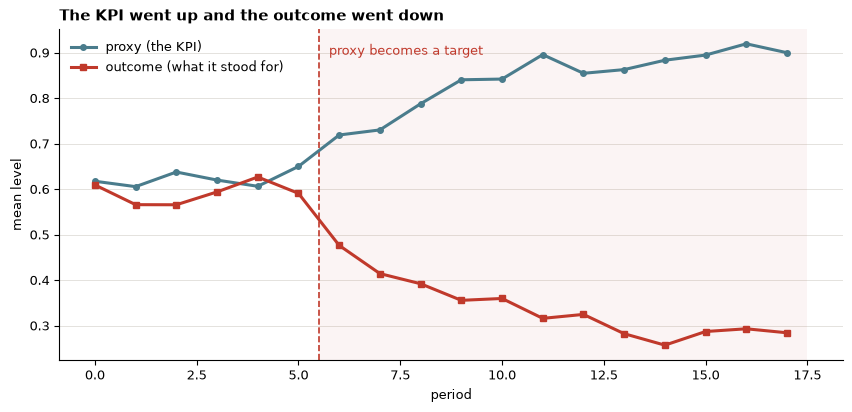

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
t = np.arange(panel.n_periods)
ax.axvspan(panel.t_target - .5, panel.n_periods - .5, color=RED, alpha=.05, lw=0)
ax.axvline(panel.t_target - .5, color=RED, ls="--", lw=1.2)
ax.text(panel.t_target - .35, panel.proxy.mean(1).max(), " proxy becomes a target",
        color=RED, fontsize=9, va="top")
ax.plot(t, panel.proxy.mean(1), color=BLUE, lw=2.2, marker="o", ms=4, label="proxy (the KPI)")
ax.plot(t, panel.outcome.mean(1), color=RED, lw=2.2, marker="s", ms=4,
        label="outcome (what it stood for)")
ax.set_xlabel("period"); ax.set_ylabel("mean level")
ax.set_title("The KPI went up and the outcome went down", loc="left", fontweight="bold")
ax.legend(frameon=False); ax.grid(axis="y", color="#e4e2dd", lw=.7); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 4. The correlation barely moves

The obvious alarm is "watch corr(proxy, outcome) and act when it breaks". Below,
the amount of gaming is swept from mild to severe. The outcome collapses. The
correlation does not.

In [4]:
rows = []
for med in (3.0, 2.2, 1.9, 1.8, 1.7, 1.5, 1.2):
    w = replace(W, scruple_median=med)
    pn = simulate(w, regime="continuous")
    r0 = np.corrcoef(pn.pre(pn.proxy), pn.pre(pn.outcome))[0, 1]
    r1 = np.corrcoef(pn.post(pn.proxy), pn.post(pn.outcome))[0, 1]
    u = pn.post(pn.diverted).mean()
    rows.append({"effort diverted": f"{100*u:.0f}%",
                 "rho before": round(r0, 4), "rho after": round(r1, 4),
                 "d rho": round(r1 - r0, 4),
                 "% of outcome destroyed":
                     f"{100*w.outcome_cost*u/pn.pre(pn.outcome).mean():.1f}%"})
sweep = pd.DataFrame(rows)
display(sweep)
print("\nTwo thirds of the outcome can be gone while the correlation slides one decimal.")

,effort diverted,rho before,rho after,d rho,% of outcome destroyed
0,14%,0.799,0.7440,-0.0550,14.7%
1,31%,0.799,0.7083,-0.0907,31.7%
2,41%,0.799,0.6978,-0.1013,41.6%
3,46%,0.799,0.6951,-0.1039,46.2%
4,48%,0.799,0.6944,-0.1046,48.2%
5,56%,0.799,0.6936,-0.1054,56.3%
6,66%,0.799,0.7012,-0.0978,67.3%



Two thirds of the outcome can be gone while the correlation slides one decimal.


## 5. The result that matters: the correlation falls without anyone gaming

A proxy becomes *the* proxy because it correlated best out of several candidates.
Selection is not free. The winner's measured correlation is its true correlation
plus whatever noise helped it win, and that noise does not come back next period.

Below there are twelve candidate proxies, **nobody games anything**, and the
chosen one still decays - by more than real gaming produced above.

In [5]:
def simulate_candidates(world, betas, n_periods=12, seed=7):
    rng = np.random.default_rng(seed)
    n, k = world.n_agents, len(betas)
    latent = np.repeat((rng.standard_normal(n) + world.kappa)[None, :], n_periods, axis=0)
    y = world.a_y * latent + world.sigma_y * rng.standard_normal((n_periods, n))
    P = (betas[:, None, None] * latent[None, :, :]
         + world.sigma_p * rng.standard_normal((k, n_periods, n)))
    return y, P


k, reps, sizes = 12, 150, (15, 30, 60, 120, 300, 900, 3600)
curse = []
for n_select in sizes:
    win, rnd = [], []
    for rep in range(reps):
        rng = np.random.default_rng(9000 + rep)
        betas = rng.uniform(0.55, 1.15, k)
        y, P = simulate_candidates(W, betas, seed=int(rng.integers(1, 2**31)))
        fy, fP = y.ravel(), P.reshape(k, -1)
        idx = rng.choice(fy.size, n_select, replace=False)
        sel = np.array([np.corrcoef(fP[j][idx], fy[idx])[0, 1] for j in range(k)])
        a, b = int(np.argmax(sel)), int(rng.integers(0, k))
        win.append(np.corrcoef(fP[a], fy)[0, 1] - sel[a])
        rnd.append(np.corrcoef(fP[b], fy)[0, 1] - sel[b])
    curse.append((n_select, float(np.mean(win)), float(np.mean(rnd))))

print(f"{'chosen on':>10}  {'chosen proxy':>13}  {'random proxy':>13}")
for n_select, wv, rv in curse:
    print(f"{n_select:>10}  {wv:>+13.4f}  {rv:>+13.4f}")
print(f"\nReal gaming, at its worst above, moved the correlation "
      f"{sweep['d rho'].min():+.4f}.")
print(f"Selection alone, with the exploit switched OFF, moves it {curse[0][1]:+.4f}.")

 chosen on   chosen proxy   random proxy
        15        -0.0972        +0.0212
        30        -0.0547        +0.0138
        60        -0.0366        +0.0130
       120        -0.0218        -0.0002
       300        -0.0117        -0.0000
       900        -0.0056        +0.0001
      3600        -0.0008        +0.0004

Real gaming, at its worst above, moved the correlation -0.1054.
Selection alone, with the exploit switched OFF, moves it -0.0972.


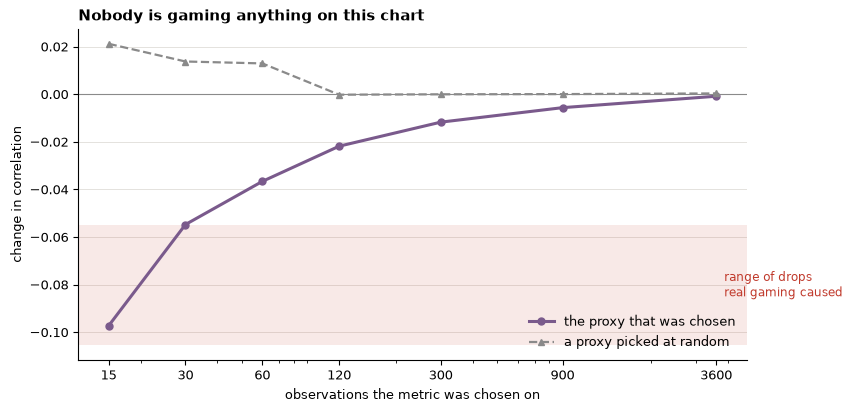

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
worst, mild = sweep["d rho"].min(), sweep["d rho"].max()
ax.axhspan(worst, mild, color=RED, alpha=.11, lw=0)
ax.text(sizes[-1], (worst + mild) / 2, "  range of drops\n  real gaming caused",
        fontsize=8.5, color=RED, va="center")
ax.plot([c[0] for c in curse], [c[1] for c in curse], color=PURPLE, lw=2.2,
        marker="o", ms=5, label="the proxy that was chosen")
ax.plot([c[0] for c in curse], [c[2] for c in curse], color=MUTED, lw=1.6, ls="--",
        marker="^", ms=4, label="a proxy picked at random")
ax.axhline(0, color=MUTED, lw=.8)
ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes])
ax.set_xlabel("observations the metric was chosen on")
ax.set_ylabel("change in correlation")
ax.set_title("Nobody is gaming anything on this chart", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", color="#e4e2dd", lw=.7); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

So "the correlation fell" is **not** evidence of Goodharting unless you know how
much data the metric was picked on. The two causes overlap across the whole range
a metric review would plausibly see.

## 6. Seven detectors

Three of them never look at the outcome. That matters more than it sounds like it
should, because the outcome is late - lateness is the reason a proxy exists.

In [7]:
def _fz(r, n):
    r = float(np.clip(r, -.999999, .999999))
    return float(np.arctanh(r)), float(1 / np.sqrt(max(n - 3, 1)))


def _drop(a1, b1, a2, b2, name, needs):
    r1 = float(np.corrcoef(a1, b1)[0, 1]); r2 = float(np.corrcoef(a2, b2)[0, 1])
    z1, s1 = _fz(r1, a1.size); z2, s2 = _fz(r2, a2.size)
    return dict(detector=name, sees="outcome" if needs else "proxy only",
                stat=round(r2 - r1, 4), p=float(stats.norm.sf((z1 - z2) / np.hypot(s1, s2))))


def corr_drop(pn):
    return _drop(pn.pre(pn.proxy), pn.pre(pn.outcome),
                 pn.post(pn.proxy), pn.post(pn.outcome), "corr_drop", True)


def holdout_divergence(pn):
    return _drop(pn.pre(pn.proxy), pn.pre(pn.holdout),
                 pn.post(pn.proxy), pn.post(pn.holdout), "holdout_divergence", False)


def rank_reshuffle(pn):
    r1 = stats.spearmanr(pn.pre(pn.proxy), pn.pre(pn.outcome)).statistic
    r2 = stats.spearmanr(pn.post(pn.proxy), pn.post(pn.outcome)).statistic
    z1, s1 = _fz(r1, pn.pre(pn.proxy).size); z2, s2 = _fz(r2, pn.post(pn.proxy).size)
    return dict(detector="rank_reshuffle", sees="outcome", stat=round(r2 - r1, 4),
                p=float(stats.norm.sf((z1 - z2) / np.hypot(s1, s2))))


def residual_trend(pn):
    m, c = np.polyfit(pn.pre(pn.proxy), pn.pre(pn.outcome), 1)
    res = pn.post(pn.outcome) - (m * pn.post(pn.proxy) + c)
    t, p2 = stats.ttest_1samp(res, 0.0)
    return dict(detector="residual_trend", sees="outcome", stat=round(float(res.mean()), 4),
                p=float(p2 / 2 if t < 0 else 1 - p2 / 2))


def ratio_shift(pn, n_boot=800):
    ap, ay, bp, by = pn.pre(pn.proxy), pn.pre(pn.outcome), pn.post(pn.proxy), pn.post(pn.outcome)
    obs = by.sum() / bp.sum() - ay.sum() / ap.sum()
    rng = np.random.default_rng(11)
    i = rng.integers(0, ap.size, (n_boot, ap.size)); j = rng.integers(0, bp.size, (n_boot, bp.size))
    dd = by[j].sum(1) / bp[j].sum(1) - ay[i].sum(1) / ap[i].sum(1)
    return dict(detector="ratio_shift", sees="outcome", stat=round(float(obs), 4),
                p=float((int((dd >= 0).sum()) + 1) / (n_boot + 1)))


def bunching(pn, width=0.35):
    if pn.threshold is None:
        return dict(detector="bunching", sees="proxy only", stat=None, p=1.0)
    hi, lo = pn.threshold + width, pn.threshold - width
    def cnt(v):
        return (((v >= pn.threshold) & (v < hi)).sum(), ((v >= lo) & (v < pn.threshold)).sum())
    ah, al = cnt(pn.pre(pn.proxy)); bh, bl = cnt(pn.post(pn.proxy))
    tab = np.array([[bh, bl], [ah, al]])
    if tab.min() == 0:
        return dict(detector="bunching", sees="proxy only", stat=None, p=1.0)
    _, p2, _, _ = stats.chi2_contingency(tab)
    r_post, r_pre = bh / bl, ah / al
    return dict(detector="bunching", sees="proxy only", stat=round(float(r_post - r_pre), 4),
                p=float(p2 / 2 if r_post > r_pre else 1 - p2 / 2))


def dispersion_shift(pn):
    a, b = pn.pre(pn.proxy), pn.post(pn.proxy)
    f = np.var(a, ddof=1) / np.var(b, ddof=1)
    p2 = 2 * min(stats.f.cdf(f, a.size - 1, b.size - 1), stats.f.sf(f, a.size - 1, b.size - 1))
    return dict(detector="dispersion_shift", sees="proxy only",
                stat=round(float(np.std(b) - np.std(a)), 4), p=float(p2))


DETECTORS = [corr_drop, ratio_shift, residual_trend, rank_reshuffle,
             holdout_divergence, bunching, dispersion_shift]

quota = simulate(W, regime="threshold")
tbl = pd.DataFrame([f(quota) for f in DETECTORS]).sort_values("p")
tbl["fires at 0.05"] = np.where(tbl["p"] < 0.05, "FIRES", "-")
display(tbl.style.format({"p": "{:.2e}"}).hide(axis="index"))

detector,sees,stat,p,fires at 0.05
bunching,proxy only,1.362100,1.32e-19,FIRES
holdout_divergence,proxy only,-0.016900,1.31e-02,FIRES
rank_reshuffle,outcome,-0.017100,2.04e-02,FIRES
corr_drop,outcome,-0.015100,2.41e-02,FIRES
residual_trend,outcome,-0.009700,1.16e-01,-
ratio_shift,outcome,-0.018000,1.82e-01,-
dispersion_shift,proxy only,0.007400,6.53e-01,-


### Why `bunching` wins on a quota

It has something to look at that the others do not: the *shape* of the
distribution around the line. Agents top up to just clear it, which leaves excess
mass immediately above the threshold and a hole immediately below.

It needs no outcome at all - and it is worth nothing against a "make it go up"
target, where there is no line to bunch against.

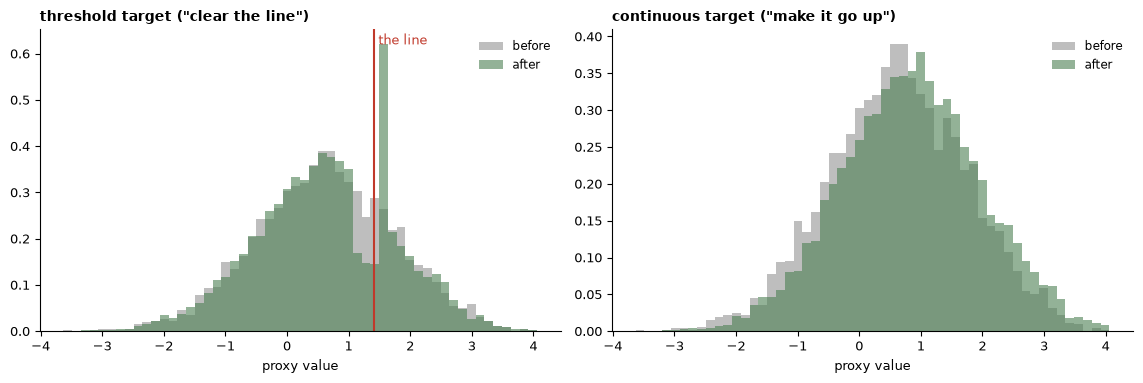

bunching on the quota:      excess-mass ratio +1.362, p = 1.32e-19
bunching on 'make it go up': None (there is no line to bunch against)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for ax, (pn, label) in zip(axes, [(quota, 'threshold target ("clear the line")'),
                                  (panel, 'continuous target ("make it go up")')]):
    bins = np.linspace(pn.pre(pn.proxy).min(), pn.pre(pn.proxy).max(), 55)
    ax.hist(pn.pre(pn.proxy), bins=bins, density=True, alpha=.55, color=MUTED, label="before")
    ax.hist(pn.post(pn.proxy), bins=bins, density=True, alpha=.6, color=GREEN, label="after")
    if pn.threshold is not None:
        ax.axvline(pn.threshold, color=RED, lw=1.5)
        ax.text(pn.threshold, ax.get_ylim()[1] * .95, " the line", color=RED, fontsize=9)
    ax.set_title(label, loc="left", fontweight="bold", fontsize=10)
    ax.set_xlabel("proxy value"); ax.legend(frameon=False, fontsize=8.5)
b_q, b_c = bunching(quota), bunching(panel)
plt.tight_layout(); plt.show()
print(f"bunching on the quota:      excess-mass ratio {b_q['stat']:+.3f}, p = {b_q['p']:.2e}")
print(f"bunching on 'make it go up': {b_c['stat']} (there is no line to bunch against)")

## 7. The outcome arrives too late to help

Every outcome-based detector needs post-target outcome data. If the outcome is
reported four periods behind - which is *why* somebody proxied it - the detector
cannot be computed until period six, by which time a third of the damage is done.

Below: cumulative damage, with each detector marked at the first period it fires.

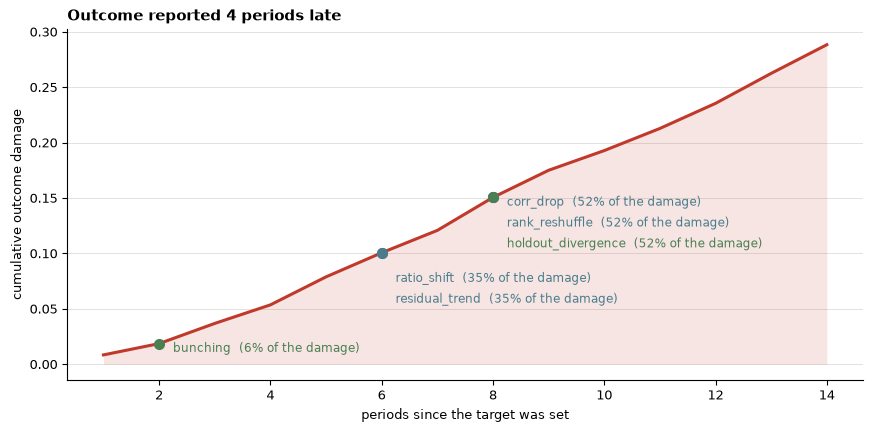

In [9]:
LAG, ALPHA = 4, 0.05
quota14 = simulate(W, regime="threshold", n_post=14)
dmg = np.cumsum(W.outcome_cost * quota14.diverted[quota14.t_target:].mean(axis=1))

fires = {}
for f in DETECTORS:
    needs = f(quota14)["sees"] == "outcome"
    for t in range(quota14.t_target + 2, quota14.n_periods + 1):
        win = t - LAG if needs else t
        if win < quota14.t_target + 2:
            continue
        sub = Panel(quota14.proxy[:win], quota14.outcome[:win], quota14.holdout[:win],
                    quota14.diverted[:win], quota14.t_target, quota14.threshold)
        if f(sub)["p"] < ALPHA:
            fires[f(quota14)["detector"]] = (t - quota14.t_target, needs)
            break

fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(1, len(dmg) + 1)
ax.fill_between(x, 0, dmg, color=RED, alpha=.13, lw=0); ax.plot(x, dmg, color=RED, lw=2.2)
for i, (name, (per, needs)) in enumerate(sorted(fires.items(), key=lambda kv: kv[1][0])):
    col = BLUE if needs else GREEN
    ax.plot([per], [dmg[per - 1]], "o", ms=7, color=col, zorder=5)
    ax.annotate(f"{name}  ({100*dmg[per-1]/dmg[-1]:.0f}% of the damage)",
                xy=(per, dmg[per - 1]), xytext=(10, -6 - 15 * (i % 3)),
                textcoords="offset points", fontsize=8.5, color=col)
ax.set_xlabel("periods since the target was set"); ax.set_ylabel("cumulative outcome damage")
ax.set_title(f"Outcome reported {LAG} periods late", loc="left", fontweight="bold")
ax.grid(axis="y", color="#e4e2dd", lw=.7); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 8. What survives

1. **The proxy did its job and the outcome still fell.** Roughly one outcome point
   destroyed per proxy point gained, from a proxy that correlated 0.80 with the
   outcome before it became a target.
2. **A correlation drop is not evidence.** Selection on a short history produces a
   drop as large as real gaming does, with nobody gaming anything.
3. **The detectors that arrive in time are the ones that never look at the outcome.**
   `bunching` on a quota; `holdout_divergence` on either kind of target.
4. **`bunching` is not portable.** First place against a threshold, worth nothing
   against "make it go up". Detection has to be chosen against the *shape of the
   target*, not installed once.
5. **Nothing detects Goodharting from the KPI alone.** Every detector that worked
   needed a second series the target did not control. A single number going up
   carries no information about whether it should be trusted.

The practical move is not a better statistic. It is to keep one sibling metric
off every dashboard and out of every bonus, so there is something honest left to
compare against - and to know it stops working the moment it leaks.

## 9. Try your own

In [10]:
# Change the world and re-run. Some things to try:
#
#   1. gamma below beta*kappa -> the exploit stops paying and nobody games.
#      my_world = replace(W, gamma=0.40)
#
#   2. A tiny org. Which detectors still work at 60 branches?
#      my_world = replace(W, n_agents=60)
#
#   3. A noisier proxy. Does bunching survive it?
#      my_world = replace(W, sigma_p=1.10)
#
#   4. Move the quota line. threshold_q=0.95 targets only the top of the
#      distribution -- fewer agents can reach it, so is the bunch still visible?
#      pn = simulate(W, regime="threshold", threshold_q=0.95)

my_world = replace(W, gamma=0.40)          # <- edit me
pn = simulate(my_world, regime="threshold")

print(f"exploit edge {my_world.exploit_edge:+.2f}  "
      f"(negative means honest work is the cheaper way to move the number)")
print(f"effort diverted: {100*pn.post(pn.diverted).mean():.1f}%")
print(f"proxy {pn.post(pn.proxy).mean() - pn.pre(pn.proxy).mean():+.4f}   "
      f"outcome {pn.post(pn.outcome).mean() - pn.pre(pn.outcome).mean():+.4f}\n")
out = pd.DataFrame([f(pn) for f in DETECTORS]).sort_values("p")
out["fires at 0.05"] = np.where(out["p"] < 0.05, "FIRES", "-")
display(out.style.format({"p": "{:.2e}"}).hide(axis="index"))

exploit edge -0.20  (negative means honest work is the cheaper way to move the number)
effort diverted: 0.0%
proxy -0.0065   outcome +0.0183



detector,sees,stat,p,fires at 0.05
holdout_divergence,proxy only,-0.005000,2.48e-01,-
corr_drop,outcome,-0.002600,3.62e-01,-
rank_reshuffle,outcome,0.000400,5.20e-01,-
dispersion_shift,proxy only,-0.004100,7.95e-01,-
ratio_shift,outcome,0.039800,9.43e-01,-
bunching,proxy only,-0.164400,9.71e-01,-
residual_trend,outcome,0.023500,9.98e-01,-


---

**[`goodhart-detector`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/goodhart-detector)** - Day 162 of
[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder).

The repo version carries the full argument: detector power and AUC under a
measured null, the sample size each detector needs, the holdout-leakage cliff,
and a calibration finding (`residual_trend` has the best raw power on a quota and
a false-positive rate 3.5x its nominal alpha, because it ignores the error in its
own pre-period fit).

```bash
pip install -r requirements.txt
python evidence.py          # the whole argument, eight sections
python -m pytest -q         # 34 tests
streamlit run app.py        # move the exploit and watch the detectors
```